# HuRI Ground Truth Collection
Build a **binary physical-interaction** ground truth from the **Human Reference Interactome (HuRI)** for the protein embedding benchmark.

HuRI (Luck et al., *Nature* 2020) is a systematic, all-by-all **yeast two-hybrid (Y2H)** screen of the human ORFeome. Unlike CORUM (complex co-membership), STRING (integrated/functional), or OmniPath (TF regulation), HuRI edges are **direct binary physical interactions** detected experimentally — a distinct evidence type.

**Source dataset:** `HuRI.tsv` (version **HI-III-19**) from http://www.interactome-atlas.org — 52,548 interactions among 8,272 genes, columns are **Ensembl gene IDs (ENSG)**.

**Choices for this build:**
- **All HuRI edges** are positives.
- Ensembl gene IDs are mapped to **UniProt Swiss-Prot** accessions (via `mygene`); a gene mapping to several accessions expands to all of them.
- HuRI is already undirected/binary; pairs are stored symmetrically.
- Negatives = pairs where both proteins are in the HuRI network but no edge was reported (standard definition, matching the other matrices).

Same matrix structure as the other notebooks: `1` positive, `0` negative, `NaN` = at least one protein outside the HuRI network. Proteins are ordered using the **shared** `ground_truth_proteins.tsv` index so this matrix aligns row-for-row with CORUM / STRING / KEGG / Reactome / GO CC / OmniPath.

In [1]:
import ssl
import urllib.request
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch
import mygene

## 0. Locate the shared ground-truth folder

The canonical protein universe lives in `protgpt/ppi_ground_truth/ground_truth_proteins.tsv` (20,431 alphabetically-sorted UniProt accessions). All shipped matrices are `(20431, 20431)`, so we key off this file to guarantee alignment.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'protgpt' / 'ppi_ground_truth').is_dir():
            return p
    raise FileNotFoundError('could not locate protgpt/ppi_ground_truth from ' + str(start))

REPO = find_repo_root(Path.cwd())
GT_DIR = REPO / 'protgpt' / 'ppi_ground_truth'
PROT_TSV = GT_DIR / 'ground_truth_proteins.tsv'
DATA_DIR = Path.cwd() / '_huri_data'
DATA_DIR.mkdir(exist_ok=True)
print('repo root :', REPO)
print('gt dir    :', GT_DIR)
print('data dir  :', DATA_DIR)

repo root : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt
gt dir    : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\protgpt\ppi_ground_truth
data dir  : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\experiments\exp2\ground_truth_notebooks\_huri_data


# 1. Download the HuRI interaction table

`HuRI.tsv` is a 2-column, header-less TSV of Ensembl gene-ID pairs. (The interactome-atlas host serves a certificate whose alt-name doesn't match, so we use an unverified SSL context for this one static download.)

In [3]:
HURI_URL = 'http://www.interactome-atlas.org/data/HuRI.tsv'
huri_path = DATA_DIR / 'HuRI.tsv'

if not huri_path.exists():
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    print('Downloading HuRI.tsv ...')
    with urllib.request.urlopen(HURI_URL, context=ctx) as r, open(huri_path, 'wb') as f:
        f.write(r.read())

df_huri = pd.read_csv(huri_path, sep='\t', header=None, names=['gene_a', 'gene_b'])
print(f"HuRI interactions: {len(df_huri):,}")
genes = sorted(set(df_huri['gene_a']) | set(df_huri['gene_b']))
print(f"Unique Ensembl genes: {len(genes):,}")
print(f"Self-interactions (homodimers): {(df_huri['gene_a'] == df_huri['gene_b']).sum():,}")
df_huri.head()

HuRI interactions: 52,548
Unique Ensembl genes: 8,272
Self-interactions (homodimers): 480


,gene_a,gene_b
0,ENSG00000000005,ENSG00000061656
1,ENSG00000000005,ENSG00000099968
2,ENSG00000000005,ENSG00000104765
3,ENSG00000000005,ENSG00000105383
4,ENSG00000000005,ENSG00000114455


# 2. Map Ensembl gene IDs → UniProt accessions

HuRI is keyed by Ensembl genes; our universe is UniProt. We map `ensembl.gene → uniprot.Swiss-Prot` with `mygene` (human). The mapping is cached to `_huri_data/ens2up.json`.

In [4]:
map_cache = DATA_DIR / 'ens2up.json'
if map_cache.exists():
    ens2up = {k: set(v) for k, v in json.load(open(map_cache)).items()}
else:
    mg = mygene.MyGeneInfo()
    res = mg.querymany(genes, scopes='ensembl.gene', fields='uniprot.Swiss-Prot',
                       species='human', returnall=True)
    ens2up = {}
    for h in res['out']:
        up = h.get('uniprot', {})
        sp = up.get('Swiss-Prot') if isinstance(up, dict) else None
        if sp:
            ens2up.setdefault(h['query'], set()).update([sp] if isinstance(sp, str) else sp)
    json.dump({k: sorted(v) for k, v in ens2up.items()}, open(map_cache, 'w'))

mapped_ups = set().union(*ens2up.values()) if ens2up else set()
print(f"Genes with ≥1 Swiss-Prot accession: {len(ens2up):,} / {len(genes):,}")
print(f"Unique UniProt accessions: {len(mapped_ups):,}")

Genes with ≥1 Swiss-Prot accession: 8,186 / 8,272
Unique UniProt accessions: 8,142


# 3. Build undirected UniProt interaction pairs

For each HuRI edge, expand both genes to their UniProt accessions and emit an undirected pair `(min, max)` for every combination. Self-pairs are dropped.

In [5]:
positive_pairs = set()
huri_nodes = set()

for ga, gb in zip(df_huri['gene_a'], df_huri['gene_b']):
    ups_a = ens2up.get(ga, set())
    ups_b = ens2up.get(gb, set())
    for a in ups_a:
        huri_nodes.add(a)
        for b in ups_b:
            huri_nodes.add(b)
            if a != b:
                positive_pairs.add(tuple(sorted((a, b))))

print(f"HuRI proteins (nodes):     {len(huri_nodes):,}")
print(f"Undirected positive pairs: {len(positive_pairs):,}")

HuRI proteins (nodes):     8,142
Undirected positive pairs: 50,938


# 4. Load the canonical protein universe

Proteins ordered alphabetically — identical order and content to the other ground-truth matrices.

In [6]:
prot_df = pd.read_csv(PROT_TSV, sep='\t')
all_proteins_sorted = prot_df['protein'].tolist()
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}
assert all_proteins_sorted == sorted(all_proteins_sorted), 'universe must be alphabetical'
print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20431
Matrix shape: 20431 x 20431


In [7]:
universe = set(all_proteins_sorted)
in_both = huri_nodes & universe
huri_only = huri_nodes - universe

print(f"HuRI proteins:                  {len(huri_nodes):,}")
print(f"In both HuRI and universe:      {len(in_both):,}")
print(f"In HuRI only (not in universe): {len(huri_only):,}")
if huri_only:
    print(f"\nSample HuRI-only IDs: {sorted(huri_only)[:10]}")

HuRI proteins:                  8,142
In both HuRI and universe:      8,142
In HuRI only (not in universe): 0


# 5. Build the ground truth matrix

- `1` = positive (HuRI Y2H edge, both proteins in the universe)
- `0` = negative (both proteins in the HuRI network, no reported edge)
- `NaN` = at least one protein not in the HuRI network

"In the network" = the protein is one of the mapped HuRI proteins.

In [8]:
# Initialize all NaN
huri_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Filter HuRI nodes to the universe; set all HuRI×HuRI pairs to 0 (negative by default)
huri_in_universe = sorted(p for p in huri_nodes if p in prot_to_idx)
huri_indices = np.array([prot_to_idx[p] for p in huri_in_universe])

huri_matrix[np.ix_(huri_indices, huri_indices)] = 0.0
print(f"HuRI proteins in universe: {len(huri_indices)} / {n}")
print(f"Set {len(huri_indices)}x{len(huri_indices)} HuRI submatrix to 0 (negative)")

HuRI proteins in universe: 8142 / 20431
Set 8142x8142 HuRI submatrix to 0 (negative)


In [9]:
# Set positives from the HuRI pairs
n_set = 0
n_skipped = 0
for p1, p2 in positive_pairs:
    if p1 in prot_to_idx and p2 in prot_to_idx:
        i, j = prot_to_idx[p1], prot_to_idx[p2]
        huri_matrix[i, j] = 1.0
        huri_matrix[j, i] = 1.0
        n_set += 1
    else:
        n_skipped += 1

print(f"Set {n_set:,} positive pairs (both directions)")
print(f"Skipped {n_skipped:,} pairs (protein not in universe)")

Set 50,938 positive pairs (both directions)
Skipped 0 pairs (protein not in universe)


In [10]:
# Set diagonal to NaN
np.fill_diagonal(huri_matrix, np.nan)

# Verify counts
upper = huri_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(huri_matrix, huri_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):       50,938
  Negative (0):   33,091,073
  NaN:           175,560,654
  Total:         208,702,665

  Pos/Neg ratio: 0.001539


  Matrix is symmetric: True


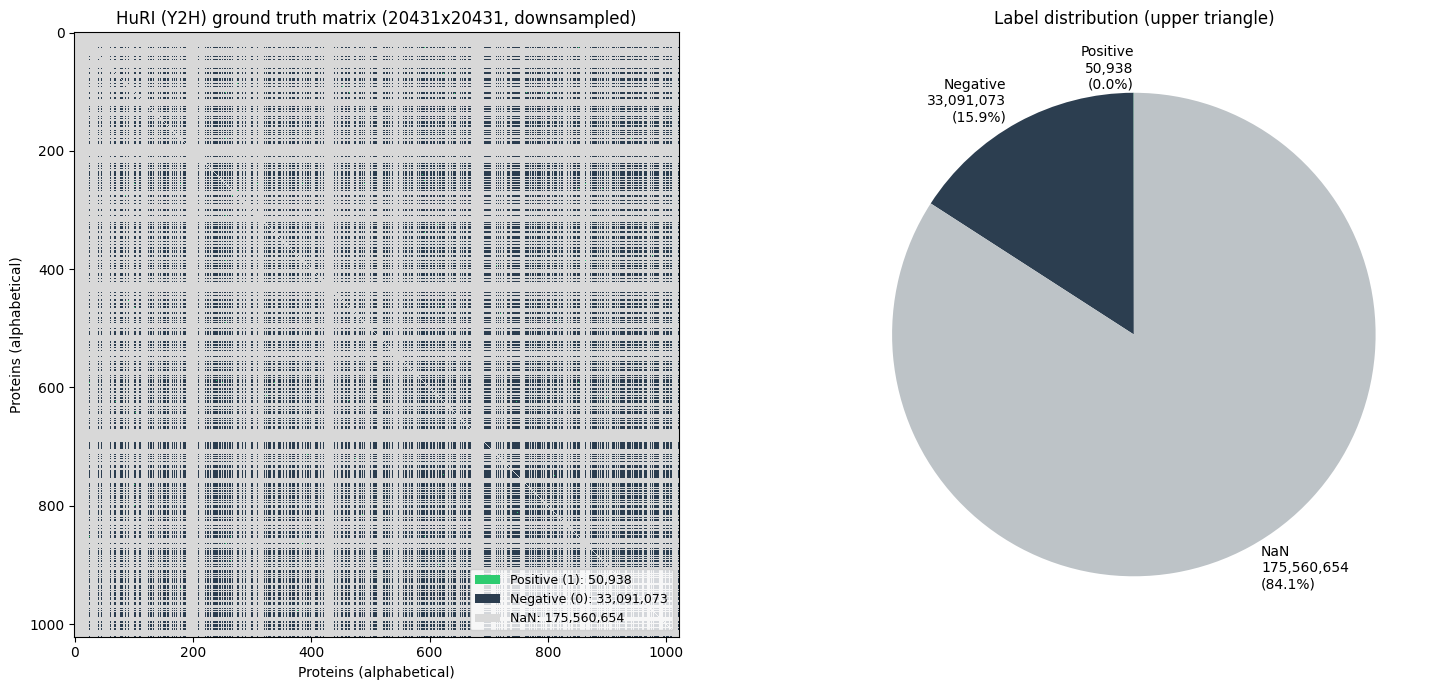

In [11]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

step = max(1, n // 1000)
display_matrix = huri_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]
rgb[neg_mask] = [0.17, 0.24, 0.31]
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"HuRI (Y2H) ground truth matrix ({n}x{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

sizes_plot = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes_plot, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save
out_npz = GT_DIR / 'huri_ground_truth_matrix.npz'

save_ppi_ground_truth(Path(GT_DIR_DEFAULT) / "huri_ground_truth_matrix.npz", huri_matrix)

npz_size = out_npz.stat().st_size / 1e6
print(f"Saved {out_npz.name} ({npz_size:.1f} MB)")
print(f"\nParameters used:")
print(f"  Source: HuRI (Human Reference Interactome), version HI-III-19")
print(f"  Assay: yeast two-hybrid (Y2H), binary physical interactions")
print(f"  Confidence filter: none (all edges)")
print(f"  ID mapping: Ensembl gene -> UniProt Swiss-Prot (mygene)")
print(f"\nTo load later:")
print(f"  matrix = np.load('huri_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved huri_ground_truth_matrix.npz (42.6 MB)
Saved huri_ground_truth_proteins.tsv

Parameters used:
  Source: HuRI (Human Reference Interactome), version HI-III-19
  Assay: yeast two-hybrid (Y2H), binary physical interactions
  Confidence filter: none (all edges)
  ID mapping: Ensembl gene -> UniProt Swiss-Prot (mygene)

To load later:
  matrix = np.load('huri_ground_truth_matrix.npz')['matrix']
  # shape (20431, 20431), values: 0, 1, NaN
